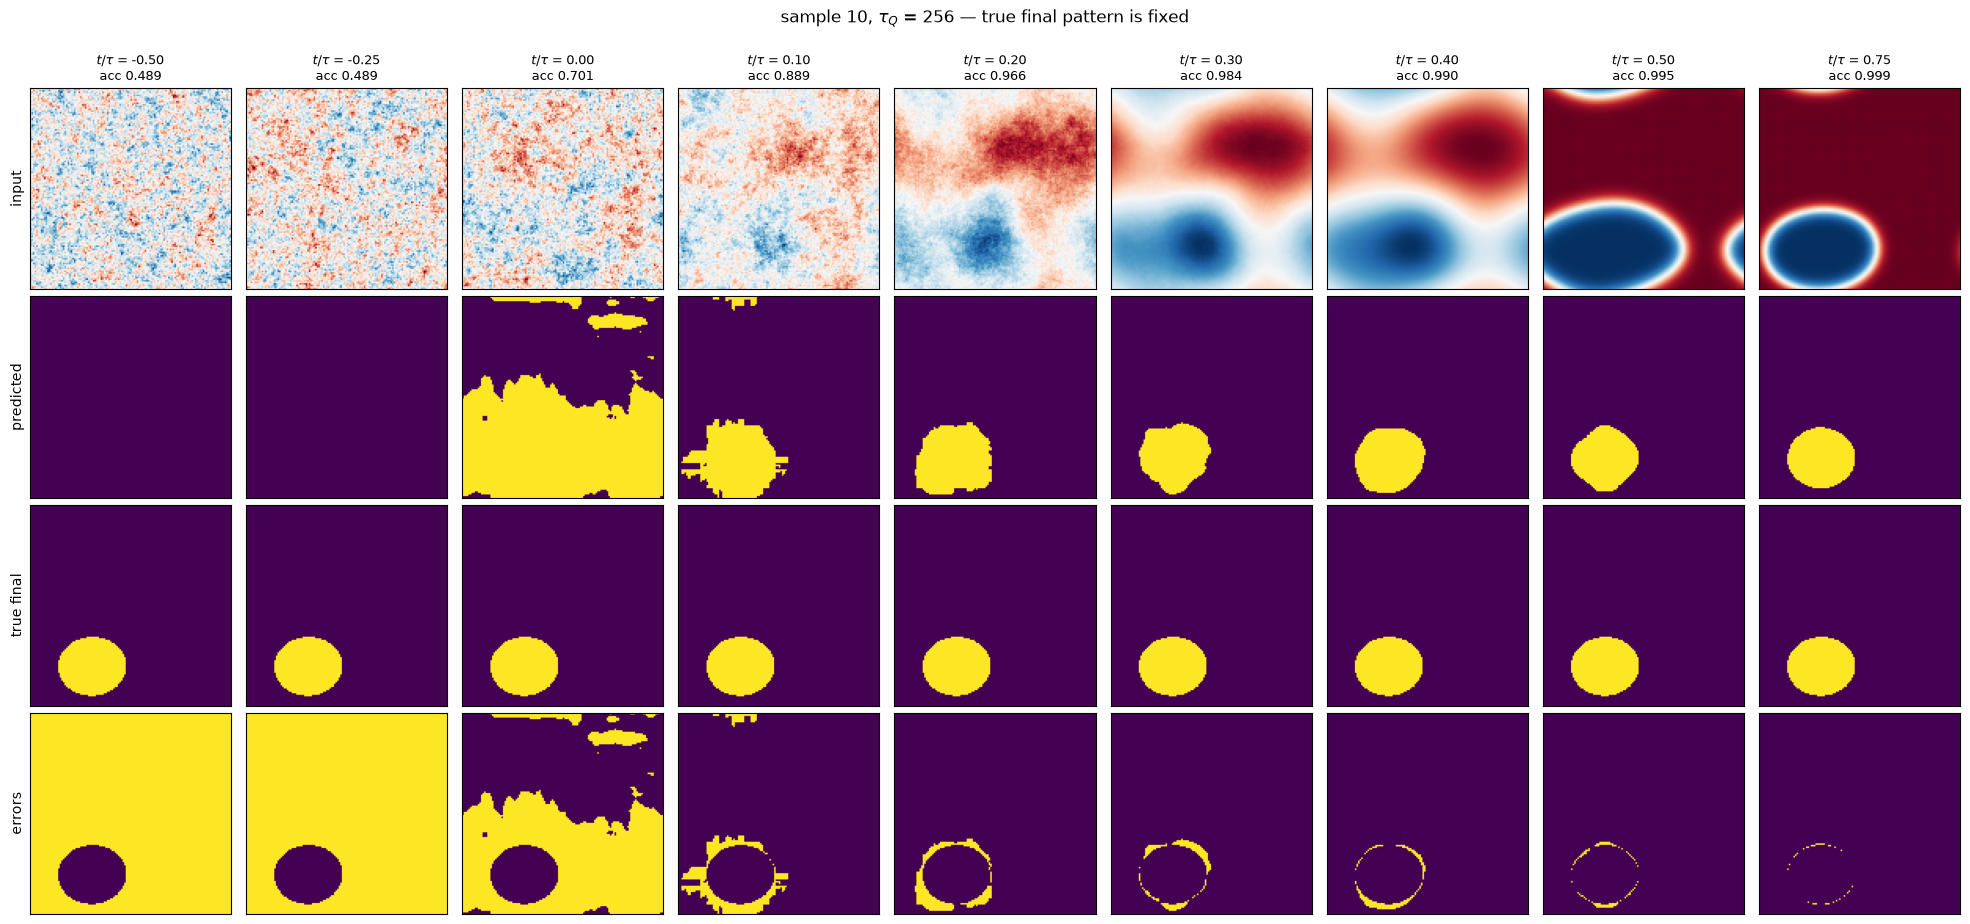

In [8]:
import sys; sys.path.insert(0, "..")
import glob, json
import numpy as np
import matplotlib.pyplot as plt
import torch
import src.kz_ml as kzml

SAMPLE = 10
TAU    = 256

tags = sorted(
    (json.load(open(f))["t_used"], f.replace(".json", ""))
    for f in glob.glob(f"../results/tau{TAU}_t*.json")
    if glob.glob(f.replace(".json", ".pt"))
)

d = np.load(f"../data/2D_tau{TAU}/chunk_000.npz")
Y = (d["phi_final"] > 0)[SAMPLE]

n = len(tags)
fig, axes = plt.subplots(4, n, figsize=(2.2*n, 9.2), squeeze=False)

for col, (t_used, tag) in enumerate(tags):
    r     = json.load(open(tag + ".json"))
    model = kzml.UNet()
    model.load_state_dict(torch.load(tag + ".pt", map_location="cpu"))
    model.eval()

    i = int(np.argmin(np.abs(d["snap_times"] - t_used)))
    x = d["snaps"][SAMPLE, i]

    with torch.no_grad():
        pred = (model(torch.from_numpy(x[None, None] / r["scale"])) > 0).numpy()[0, 0]

    axes[0, col].imshow(x, cmap="RdBu")
    axes[0, col].set_title(f"$t/\\tau$ = {t_used/TAU:.2f}\nacc {r['test_acc']:.3f}", fontsize=9)
    axes[1, col].imshow(pred)
    axes[2, col].imshow(Y)
    axes[3, col].imshow(pred != Y)

for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
for row, lab in enumerate(["input", "predicted", "true final", "errors"]):
    axes[row, 0].set_ylabel(lab, fontsize=10)

plt.suptitle(f"sample {SAMPLE}, $\\tau_Q$ = {TAU} — true final pattern is fixed", y=1.0)
plt.tight_layout()
plt.savefig(f"../figures/evolution_tau{TAU}_s{SAMPLE}.png", dpi=150)
plt.show()

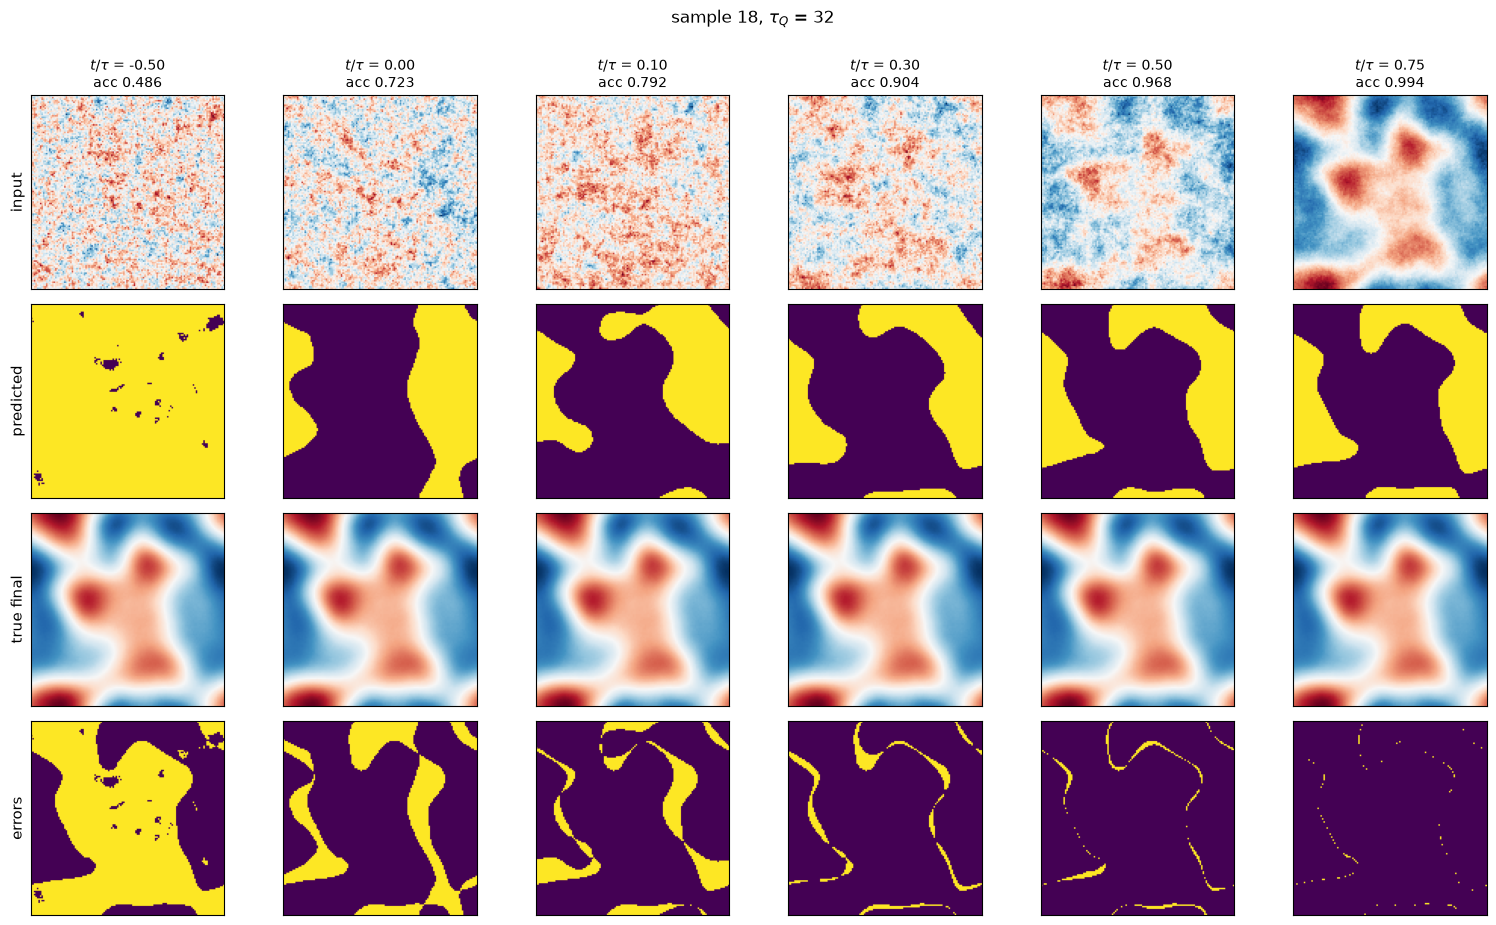

In [13]:
import sys; sys.path.insert(0, "..")
import glob, json
import numpy as np
import matplotlib.pyplot as plt
import torch
import src.kz_ml as kzml

SAMPLE = 18
TAU    = 32
WANT   = [-0.5, 0.0, 0.1, 0.3, 0.5, 0.75]

tags = sorted(
    (json.load(open(f))["t_used"], f.replace(".json", ""))
    for f in glob.glob(f"../results/tau{TAU}_t*.json")
    if glob.glob(f.replace(".json", ".pt"))
    and any(abs(json.load(open(f))["t_used"]/TAU - w) < 1e-6 for w in WANT)
)

missing = [w for w in WANT if not any(abs(t/TAU - w) < 1e-6 for t, _ in tags)]
if missing:
    print("no checkpoint for t/tau =", missing)

d = np.load(f"../data/2D_tau{TAU}/chunk_000.npz")
Y = (d["phi_final"] > 0)[SAMPLE]

n = len(tags)
fig, axes = plt.subplots(4, n, figsize=(2.6*n, 9.2), squeeze=False)

for col, (t_used, tag) in enumerate(tags):
    r     = json.load(open(tag + ".json"))
    model = kzml.UNet()
    model.load_state_dict(torch.load(tag + ".pt", map_location="cpu"))
    model.eval()

    i = int(np.argmin(np.abs(d["snap_times"] - t_used)))
    x = d["snaps"][SAMPLE, i]

    with torch.no_grad():
        pred = (model(torch.from_numpy(x[None, None] / r["scale"])) > 0).numpy()[0, 0]

    axes[0, col].imshow(x, cmap="RdBu")
    axes[0, col].set_title(f"$t/\\tau$ = {t_used/TAU:.2f}\nacc {r['test_acc']:.3f}", fontsize=10)
    axes[1, col].imshow(pred)
    axes[2, col].imshow(d["phi_final"][SAMPLE], cmap="RdBu")
    axes[3, col].imshow(pred != Y)

for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
for row, lab in enumerate(["input", "predicted", "true final", "errors"]):
    axes[row, 0].set_ylabel(lab, fontsize=11)

plt.suptitle(f"sample {SAMPLE}, $\\tau_Q$ = {TAU}", y=1.0)
plt.tight_layout()
plt.savefig(f"../figures/evolution_tau{TAU}_s{SAMPLE}.png", dpi=150)
plt.show()

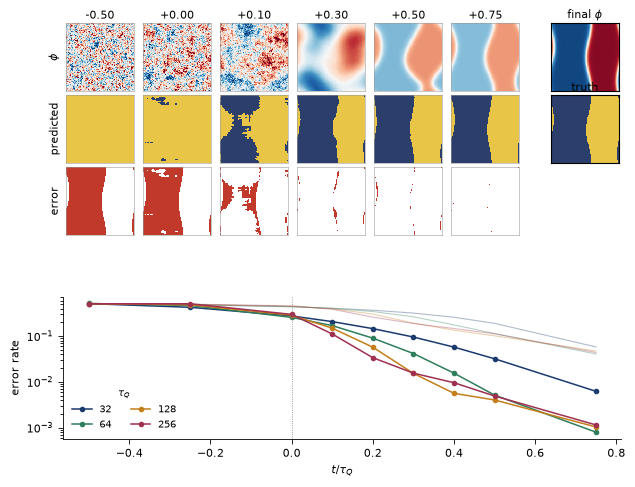

In [19]:
import sys; sys.path.insert(0, "..")
import glob, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs
from matplotlib.colors import ListedColormap
import torch
import src.kz_ml as kzml
import src.analysis as an

SAMPLE, TAU = 12, 256
WANT = [-0.5, 0.0, 0.1, 0.3, 0.5, 0.75]

plt.rcParams.update({
    "font.size": 8, "font.family": "sans-serif",
    "axes.linewidth": 0.6, "xtick.major.width": 0.6,
    "ytick.major.width": 0.6, "savefig.bbox": "tight",
})

DOM = ListedColormap(["#2c3e6b", "#e8c547"])      # down / up
ERR = ListedColormap([(0, 0, 0, 0), "#c0392b"])   # transparent / error

tags = sorted(
    (json.load(open(f))["t_used"], f.replace(".json", ""))
    for f in glob.glob(f"../results/tau{TAU}_t*.json")
    if glob.glob(f.replace(".json", ".pt"))
    and any(abs(json.load(open(f))["t_used"]/TAU - w) < 1e-6 for w in WANT)
)

d = np.load(f"../data/2D_tau{TAU}/chunk_000.npz")
Y = (d["phi_final"] > 0)[SAMPLE]
n = len(tags)

fig = plt.figure(figsize=(7.2, 5.4))
outer = gs.GridSpec(2, 1, height_ratios=[3, 2], hspace=0.35, figure=fig)
top   = gs.GridSpecFromSubplotSpec(3, n + 2, subplot_spec=outer[0],
                                   width_ratios=[1]*n + [0.25, 1],
                                   wspace=0.06, hspace=0.06)

for col, (t_used, tag) in enumerate(tags):
    r = json.load(open(tag + ".json"))
    model = kzml.UNet()
    model.load_state_dict(torch.load(tag + ".pt", map_location="cpu"))
    model.eval()

    i = int(np.argmin(np.abs(d["snap_times"] - t_used)))
    x = d["snaps"][SAMPLE, i]
    with torch.no_grad():
        pred = (model(torch.from_numpy(x[None, None] / r["scale"])) > 0).numpy()[0, 0]

    v = 2.5 * x.std()
    for row, (img, cm, kw) in enumerate([
            (x, "RdBu_r", dict(vmin=-v, vmax=v)),
            (pred, DOM, dict(vmin=0, vmax=1)),
            (pred != Y, ERR, dict(vmin=0, vmax=1))]):
        ax = fig.add_subplot(top[row, col])
        ax.imshow(img, cmap=cm, interpolation="nearest", **kw)
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values():
            s.set_linewidth(0.4); s.set_color("0.6")
        if row == 0:
            ax.set_title(f"{t_used/TAU:+.2f}", fontsize=8, pad=3)
        if row == 1:
            ax.text(0.5, -0.09, f"{r['test_acc']:.3f}", fontsize=7,
                    ha="center", va="top", transform=ax.transAxes, color="0.35")
        if col == 0:
            ax.set_ylabel(["$\\phi$", "predicted", "error"][row], fontsize=8)

# reference panels, set apart: continuous field above binary truth
v_f = 1.1 * np.abs(d["phi_final"][SAMPLE]).max()

axf = fig.add_subplot(top[0, n + 1])
axf.imshow(d["phi_final"][SAMPLE], cmap="RdBu_r",
           interpolation="nearest", vmin=-v_f, vmax=v_f)
axf.set_title("final $\\phi$", fontsize=8, pad=3)

axr = fig.add_subplot(top[1, n + 1])
axr.imshow(Y, cmap=DOM, interpolation="nearest", vmin=0, vmax=1)
axr.set_title("truth", fontsize=8, pad=3)

for ax in (axf, axr):
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_linewidth(0.8); s.set_color("k")
# panel b: error curves
axb = fig.add_subplot(outer[1])
for tau, c in zip([32, 64, 128, 256], ["#1b3b6f", "#2e7d5b", "#c47f1a", "#a03050"]):
    res = an.load_results(tau)
    if not res:
        continue
    t, eb, em = an.as_arrays(res)
    axb.semilogy(t/tau, em, "o-", ms=3, lw=1.1, color=c, label=f"{tau}")
    axb.semilogy(t/tau, eb, "-", lw=0.8, color=c, alpha=0.35)
axb.axvline(0, color="0.5", lw=0.6, ls=":")
axb.set_xlabel("$t/\\tau_Q$"); axb.set_ylabel("error rate")
axb.legend(title="$\\tau_Q$", fontsize=7, title_fontsize=7,
           frameon=False, loc="lower left", ncol=2)
for s in ["top", "right"]:
    axb.spines[s].set_visible(False)

plt.savefig(f"../figures/fig1_tau{TAU}.pdf")
plt.savefig(f"../figures/fig1_tau{TAU}.png", dpi=300)
plt.show()

tau=  32  xi= 23.8± 6.0   wall=  286   box/xi=5.4
tau=  64  xi= 27.1± 4.6   wall=  195   box/xi=4.7
tau= 128  xi= 28.9± 3.9   wall=  131   box/xi=4.4
tau= 256  xi= 30.8± 2.7   wall=   49   box/xi=4.2


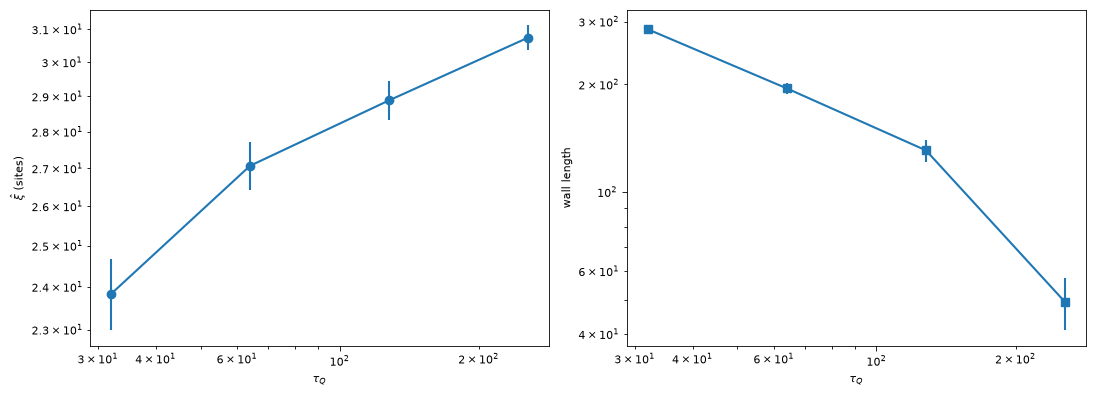

xi ~ tau^+0.120
wall ~ tau^-0.819


In [20]:
import sys; sys.path.insert(0, "..")
import numpy as np, matplotlib.pyplot as plt
import src.analysis as an

TAUS = [32, 64, 128, 256]
xi, wl, xi_e, wl_e = [], [], [], []

for tau in TAUS:
    d = an.load_chunk(tau)
    x = an.correlation_length(d["phi_final"])
    w = an.wall_length(d["phi_final"])
    xi.append(x.mean());  xi_e.append(x.std()/np.sqrt(len(x)))
    wl.append(w.mean());  wl_e.append(w.std()/np.sqrt(len(w)))
    print(f"tau={tau:4d}  xi={x.mean():5.1f}±{x.std():4.1f}   "
          f"wall={w.mean():5.0f}   box/xi={128/x.mean():.1f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].errorbar(TAUS, xi, yerr=xi_e, fmt="o-")
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("$\\tau_Q$"); ax[0].set_ylabel("$\\hat\\xi$ (sites)")

ax[1].errorbar(TAUS, wl, yerr=wl_e, fmt="s-")
ax[1].set_xscale("log"); ax[1].set_yscale("log")
ax[1].set_xlabel("$\\tau_Q$"); ax[1].set_ylabel("wall length")
plt.tight_layout(); plt.show()

# fitted exponents
for name, y in [("xi", xi), ("wall", wl)]:
    p = np.polyfit(np.log(TAUS), np.log(y), 1)
    print(f"{name} ~ tau^{p[0]:+.3f}")

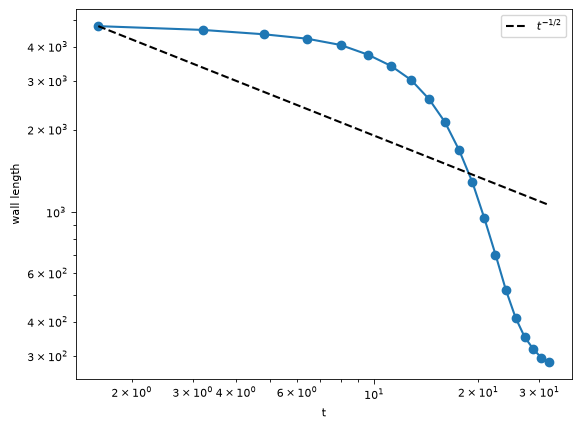

In [24]:
d = an.load_chunk(32)
wl_t = np.array([an.wall_length(d["snaps"][:, i]).mean()
                 for i in range(len(d["snap_times"]))])
t = d["snap_times"]
m = t > 0
plt.loglog(t[m], wl_t[m], "o-")
plt.loglog(t[m], wl_t[m][0]*(t[m]/t[m][0])**-0.5, "k--", label="$t^{-1/2}$")
plt.xlabel("t"); plt.ylabel("wall length"); plt.legend(); plt.show()

In [23]:
p = np.polyfit(np.log(TAUS[:3]), np.log(wl[:3]), 1)
print(f"wall ~ tau^{p[0]:+.3f}   (KZ: -nu/(1+z nu))")

wall ~ tau^-0.563   (KZ: -nu/(1+z nu))


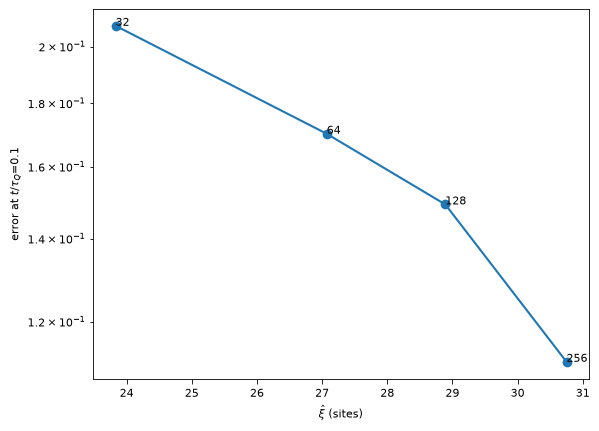

In [21]:
frac = 0.1                        # fixed t/tau
err  = []
for tau in TAUS:
    res = an.load_results(tau)
    m = [r for r in res if abs(r["t_used"]/tau - frac) < 1e-6]
    err.append(1 - m[0]["test_acc"] if m else np.nan)

err = np.array(err)
plt.plot(xi, err, "o-")
for t, x, e in zip(TAUS, xi, err):
    plt.annotate(f"{t}", (x, e), fontsize=8)
plt.xlabel("$\\hat\\xi$ (sites)"); plt.ylabel(f"error at $t/\\tau_Q$={frac}")
plt.yscale("log"); plt.show()

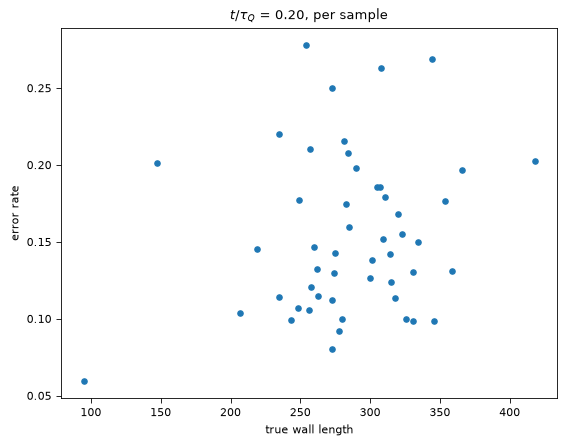

correlation: 0.196


In [22]:
d = an.load_chunk(32)
res = [r for r in an.load_results(32) if r["has_ckpt"]]
r = res[len(res)//2]
model, meta = an.load_model(r["tag"])
X, t_used = an.snapshot_at(d, meta["t_used"])
pred = an.predict(model, X, meta["scale"])
Y = d["phi_final"] > 0

acc_i = (pred == Y).mean(axis=(1, 2))
wl_i  = an.wall_length(d["phi_final"])

plt.scatter(wl_i, 1 - acc_i, s=14)
plt.xlabel("true wall length"); plt.ylabel("error rate")
plt.title(f"$t/\\tau_Q$ = {t_used/32:.2f}, per sample")
plt.show()
print("correlation:", np.corrcoef(wl_i, 1 - acc_i)[0, 1].round(3))